<a href="https://colab.research.google.com/github/caashka/programming_big_data/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B1%D0%BE%D0%BB%D1%8C%D1%88%D0%B8%D1%85_%D0%BF%D1%80%D0%BE%D1%81%D1%82%D1%80%D0%B0%D0%BD%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%8B%D1%85_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B2_%D1%81%D1%80%D0%B5%D0%B4%D0%B5_Google_Earth_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Обработка больших пространственных данных в среде Google Earth Engine**

Перед выполнением заданий необходимо ознакомиться (вспомнить) и запустить последовательно следующий материал:

1. [**Geemap. Часть 1: Подготовка среды и базовые картографические инструменты**](https://colab.research.google.com/drive/1ZQsl0L6yt4YEZ40Pb97KnTFjYK5zslcE?usp=sharing)
2. [**Geemap. Часть 2: Геопространственный анализ и экспорт результатов**](https://colab.research.google.com/drive/19wOWQc80TiZSNy9foAc8qP5EqpbaBD62?usp=sharing)
3. [**Geemap. Часть 3: Расширенные средства визуализации и анализа данных**](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing)

## **Устанавливаем необходимые зависимости и авторизуемся в Google Earth Engine (GEE)**

P.S.: Необходимо заранее создать в GEE проект и сделать его некоммерческим в настройках, см. первую часть теории.

In [2]:
%%capture
!pip install -U "geemap[workshop]"

In [3]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='onyx-robot-457623-m5') # Тут должно быть имя Вашего проекта

## **Задание 1. Визуализация данных цифровой модели рельефа (ЦМР)**



Найдите набор данных ЦМР в [Каталоге данных Earth Engine](https://developers.google.com/earth-engine/datasets) и выполните обрезку растра по границам выбранной территории (например, вашей страны, региона или города - полигоны можно загрузить в OSM). Отобразите результат с использованием подходящей **цветовой палитры**. В качестве примера на карте ниже представлена ЦМР штата Колорадо.

![](https://i.imgur.com/OLeSt7n.png)

In [ ]:
# Ваш код

## **Задание 2. Создание безоблачного композита на основе данных Sentinel-2 или Landsat**



Используйте данные [Sentinel-2](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED) или [Landsat-9](https://developers.google.com/earth-engine/datasets/catalog/landsat-9) для создания **безоблачного композитного изображения** за определённый год для выбранного вами региона. Отобразите полученное изображение на карте с применением соответствующей **комбинации спектральных каналов**. В качестве примера на карте ниже представлен безоблачный композит Sentinel-2 в синтезированных цветах (false-color) за 2021 год для штата Колорадо.

![](https://i.imgur.com/xkxpkS1.png)


In [ ]:
# Ваш код

## **Задание 3. Визуализация аэрофотоснимков NAIP**


Используйте данные [NAIP](https://developers.google.com/earth-engine/datasets/catalog/USDA_NAIP_DOQQ) (Национальная программа аэрофотосъёмки сельскохозяйственных угодий США) для создания безоблачного изображения выбранного вами округа США. В качестве примера на карте ниже представлен безоблачный композит NAIP в **натуральных цветах** (true-color) для округа Нокс, штат Теннесси. Обратите внимание, что в разных штатах могут существовать округа с одинаковыми названиями — убедитесь, что выбран корректный округ для указанного штата.

![](https://i.imgur.com/iZSGqGS.png)

In [ ]:
m = geemap.Map()
states = ee.FeatureCollection("TIGER/2018/States")
florida_boundary = states.filter(ee.Filter.eq("NAME", "Florida"))
naip_collection = (ee.ImageCollection('USDA/NAIP/DOQQ')
                   .filterDate('2018-01-01', '2021-12-31')
                   .filterBounds(florida_boundary)
                   .select(['N']))
florida_nir = naip_collection.mosaic().clip(florida_boundary)
nir_vis_params = {
    'min': 0,
    'max': 255,
    'palette': ['black', 'blue', 'cyan', 'green', 'yellow', 'red', 'magenta', 'white']
}
m.add_layer(florida_nir, nir_vis_params, 'NAIP Florida NIR')
m.center_object(florida_boundary, 7)
m

Map(center=[28.460067698576307, -82.42296617464744], controls=(WidgetControl(options=['position', 'transparent…

## **Задание 4. Визуализация границ водосборных бассейнов**



Выполните визуализацию данных [USGS Watershed Boundary Dataset](https://developers.google.com/earth-engine/datasets/catalog/USGS_WBD_2017_HUC04) (Набор данных границ водосборных бассейнов Геологической службы США), отображая **только контурные линии** без заливки полигонов.

![](https://i.imgur.com/PLlNFq3.png)

In [ ]:
m = geemap.Map(center=(40, -100), zoom=4)
watersheds = ee.FeatureCollection('USGS/WBD/2017/HUC04')
style = {
    'color': 'blue',
    'width': 2,
    'fillColor': '00000000'
}
watersheds_vis = watersheds.style(**style)
m.add_layer(watersheds_vis, {}, 'Watersheds Contours')
m

Map(center=[40, -100], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

## **Задание 5. Визуализация динамики земельного покрова**


5.1. Ознакомьтесь с примерами по ссылке: [Расширенные средства визуализации данных Earth Engine](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing#scrollTo=e2a888fb)

5.2. Используйте данные [USGS National Land Cover Database](https://developers.google.com/earth-engine/datasets/catalog/USGS_NLCD_RELEASES_2019_REL_NLCD) (Национальная база данных земельного покрова) и [US Census States](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_States) (границы штатов США) для создания **карты с разделённым экраном** (split-panel map), позволяющей визуализировать изменения земельного покрова за период 2001–2019 гг. для выбранного штата США. Не забудьте добавить на карту **легенду классификации NLCD**.

![](https://i.imgur.com/Au7Q5Ln.png)

In [ ]:
m = geemap.Map()
states = ee.FeatureCollection("TIGER/2018/States")
florida_boundary = states.filter(ee.Filter.eq("NAME", "Florida"))

nlcd_2001 = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2001').select('landcover')
nlcd_2019 = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2019').select('landcover')
nlcd_2001_florida = nlcd_2001.clip(florida_boundary)
nlcd_2019_florida = nlcd_2019.clip(florida_boundary)
left_layer = geemap.ee_tile_layer(nlcd_2001_florida, {}, 'NLCD 2001 Florida')
right_layer = geemap.ee_tile_layer(nlcd_2019_florida, {}, 'NLCD 2019 Florida')

m.center_object(florida_boundary, 7)
m.split_map(left_layer, right_layer)
m.add_legend(title='NLCD', builtin_legend='NLCD')
m

Map(center=[28.460067698576307, -82.42296617464744], controls=(ZoomControl(options=['position', 'zoom_in_text'…

## **Задание 6. Создание таймлапс-анимации на основе данных Landsat**


6.1. Ознакомьтесь с примером по ссылке: [Создание анимаций временных рядов](https://colab.research.google.com/drive/1yN5f8gJQs6ZoAyZNfjNclRv0EB83qPGz?usp=sharing#scrollTo=a7112c2c)


6.2. Сгенерируйте **покадровую анимацию** (timelapse) с использованием данных Landsat для демонстрации многолетней динамики изменений выбранной территории.

![Spain](https://github.com/user-attachments/assets/f12839c0-1c30-404d-b0ab-0fa12ce12d24)

---



In [ ]:
roi = ee.Geometry.BBox(-122.5, 37.5, -121.5, 38.5)
timelapse = geemap.landsat_timelapse(
    roi, out_gif='landsat_timelapse.gif',
    start_year=1984, end_year=2022,
    bands=['NIR', 'Red', 'Green'],
    frames_per_second=3
)
geemap.show_image(timelapse)

Generating URL...
Please wait ...
The GIF image has been saved to: /content/landsat_timelapse.gif


Output()

## **Задание 7. Классификация земного покрова с применением методов машинного обучения и отбором признаков**

7.1. Ознакомьтесь с материалом по ссылке: [Экспорт растровых данных и применение методов машинного обучения в среде Google Earth Engine](https://colab.research.google.com/drive/1BU-Q4D0XEIy2KiEtzw-3dKISE0lwGLV2?usp=sharing)

7.2. Создайте интерактивную карту и определите **область интереса** (ROI) для классификации. Область должна отличаться от примера в методическом материале.

In [60]:
m = geemap.Map()
region = m.user_roi
if region is None:
    region = ee.Geometry.BBox(-87.75, 24.125, -79.75, 31.125)

m.center_object(region, 6)
m.add_layer(region, {}, 'ROI')
m

Map(center=[27.606794875697403, -83.74999999999997], controls=(WidgetControl(options=['position', 'transparent…



7.3. Загрузите коллекцию снимков **Sentinel-2** за вегетационный период (май–сентябрь) выбранного года. Примените фильтрацию по облачности и создайте функцию **маскирования облаков** на основе канала QA60.

In [61]:
def mask_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )
    return image.updateMask(mask).divide(10000).copyProperties(
        image, ['system:time_start']
    )

In [62]:
    collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    collection = collection.filterBounds(region)
    collection = collection.filterDate('2023-05-01', '2023-09-30')

    collection = collection.filter(
        ee.Filter.lessThan('CLOUDY_PIXEL_PERCENTAGE', 20)
    )
    collection = collection.map(mask_clouds)

7.4. Создайте **безоблачный медианный композит** из отфильтрованной коллекции и отобразите его на карте в естественных цветах (RGB: B4, B3, B2).

In [63]:
median_image = collection.median()
median_image = median_image.clip(region)
vis_params = {
  'bands': ['B4', 'B3', 'B2'],  # Красный, зеленый, синий каналы
  'min': 0.0,                     # Минимальное значение отражения
  'max': 0.3,                     # Максимальное значение отражения
  'gamma': 1.4                    # Гамма-коррекция для улучшения контраста
}

map_composite = geemap.Map()
map_composite.centerObject(region, 6)
map_composite.addLayer(median_image, vis_params, 'Медианный композит RGB')
map_composite

Map(center=[27.606794875697403, -83.74999999999997], controls=(WidgetControl(options=['position', 'transparent…

7.5. Рассчитайте **спектральные индексы** и добавьте их в качестве дополнительных каналов изображения:
- **NDVI** — нормализованный вегетационный индекс
- **NDWI** — нормализованный водный индекс
- **NDBI** — нормализованный индекс застройки
- **EVI** — улучшенный вегетационный индекс

In [64]:
ndvi = median_image.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = median_image.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = median_image.normalizedDifference(['B11', 'B8']).rename('NDBI')
evi = median_image.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
    {
        'NIR': median_image.select('B8'),    # Ближний инфракрасный
        'RED': median_image.select('B4'),    # Красный
        'BLUE': median_image.select('B2')    # Синий
    }
).rename('EVI')

median_image = median_image.addBands([ndvi, ndwi, ndbi, evi])

7.6. Загрузите эталонные данные о земном покрове из набора [ESA WorldCover](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v200) и сформируйте **первичную обучающую выборку** со всеми спектральными каналами и индексами.

In [68]:
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map').clip(region)

# Объединяем спутниковые данные с картой классов
# Нам нужны только спектральные каналы и индексы + класс
bands_to_sample = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'EVI']
image_with_label = median_image.select(bands_to_sample).addBands(worldcover)

# Формируем выборку (FeatureCollection)
# # scale=10 (разрешение S2), numPixels=5000 (достаточно для теста)
training = image_with_label.sample(
    region=region,
    scale=30,
    numPixels=1000,
    seed=0,
    geometries=True # Чтобы сохранить координаты (опционально)
)

print(f"Создано обучающих точек: {training.size().getInfo()}")

Создано обучающих точек: 401


7.7. **Анализ мультиколлинеарности признаков.** Извлеките значения признаков из обучающей выборки в формат `pandas.DataFrame` и постройте **матрицу корреляции Пирсона** для всех спектральных каналов и индексов.

Визуализируйте её в виде тепловой карты (`seaborn.heatmap`).


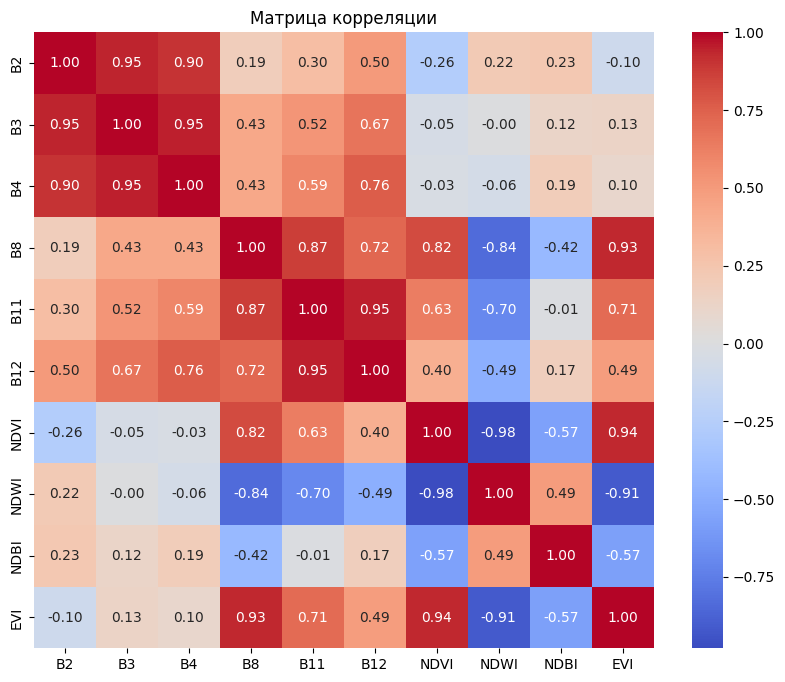

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ИСПРАВЛЕНИЕ ЗДЕСЬ: используем ee_to_df
df = geemap.ee_to_df(training)

# Оставляем только признаки (без класса 'Map')
features_cols = bands_to_sample
corr = df[features_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляции")
plt.show()


7.8. **Отбор признаков на основе корреляционного анализа.** Проанализируйте матрицу корреляции и выявите пары признаков с коэффициентом корреляции |r| > 0.85. Для каждой такой пары исключите один из признаков, руководствуясь следующими критериями:
- сохраняйте признаки с большей физической интерпретируемостью (например, NDVI предпочтительнее отдельного канала B8);
- при прочих равных сохраняйте признак с меньшим средним значением корреляции с остальными.

Сформируйте итоговый список признаков для обучения и обоснуйте исключение каждого удалённого признака в текстовой ячейке.





---

**Обоснование выбора признаков:**

Анализ матрицы  показал высокую корреляцию между каналами B2, B3, B4 (больше 0.9), поэтому был оставлен только B3. Канал B8 был исключен из-за корреляции 0.93 с индексом EVI, который более информативен для растительности. Пара B11 и B12 имеет корреляцию 0.95, оставлен B12. Индексы NDVI и NDWI имеют экстремально высокую обратную корреляцию (-0.98), поэтому NDVI был исключен в пользу NDWI и EVI. Итоговый набор: ['B3', 'B12', 'NDWI', 'NDBI', 'EVI'].

---

In [71]:
final_features = ['B3', 'B12', 'NDWI', 'NDBI', 'EVI']

7.9. Разделите данные на **обучающую (70%)** и **валидационную (30%)** выборки.


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score, classification_report

sample_with_random = training.randomColumn('random')

train_data = sample_with_random.filter(ee.Filter.lt('random', 0.7))
val_data = sample_with_random.filter(ee.Filter.gte('random', 0.7))

print(f"Обучающая выборка: {train_data.size().getInfo()}")
print(f"Валидационная выборка: {val_data.size().getInfo()}")

Обучающая выборка: 274
Валидационная выборка: 127


7.10. Обучите не менее **трёх классификаторов** (например, Random Forest, Gradient Boosting и SVM) на **сокращённом наборе признаков**. Для каждой модели вычислите **матрицу ошибок**, **общую точность** (Overall Accuracy) и **коэффициент Каппа**.

In [78]:
import numpy as np

label = 'Map'
bands = final_features

classifiers = {
    'Random Forest': ee.Classifier.smileRandomForest(100),
    'Gradient Boosting': ee.Classifier.smileGradientTreeBoost(100),
    'SVM': ee.Classifier.libsvm()
}
models = {}
results = {}
for name, clf in classifiers.items():
    model = clf.train(
        features=train_data,
        classProperty=label,
        inputProperties=bands
    )
    models[name] = model
    validated = val_data.classify(model)
    error_matrix = validated.errorMatrix(label, 'classification')
    accuracy = error_matrix.accuracy().getInfo()
    kappa = error_matrix.kappa().getInfo()
    matrix = np.array(error_matrix.getInfo())

    results[name] = {
        'accuracy': accuracy,
        'kappa': kappa,
        'matrix': matrix
    }

    print(f"{name}: Точность = {accuracy:.3f}, Каппа = {kappa:.3f}")

Обучающая выборка: 274
Валидационная выборка: 127
Обучение моделей...
Random Forest: Точность = 0.717, Каппа = 0.615
Gradient Boosting: Точность = 0.709, Каппа = 0.600
SVM: Точность = 0.724, Каппа = 0.589


7.11. Для сравнения обучите **один из классификаторов** (например, Random Forest) на **полном наборе признаков** (без отбора). Сравните метрики точности и сделайте вывод о влиянии отбора признаков на качество классификации.


In [87]:
first_feature = train_data.first()
all_bands = first_feature.propertyNames().remove('random').remove('Map').remove('system:index')
rf_full = ee.Classifier.smileRandomForest(100).train(
    features=train_data,
    classProperty='Map',
    inputProperties=all_bands
)
validated_full = val_data.classify(rf_full)
error_matrix_full = validated_full.errorMatrix('Map', 'classification')
acc_full = error_matrix_full.accuracy().getInfo()
kappa_full = error_matrix_full.kappa().getInfo()
matrix = np.array(error_matrix.getInfo())

results['RF Full'] = {
    'accuracy': acc_full,
    'kappa': kappa_full,
    'matrix': matrix
}

print(f"Random Forest (Full Features): Точность = {acc_full:.3f}, Каппа = {kappa_full:.3f}")

Random Forest (Full Features): Точность = 0.717, Каппа = 0.616


---




**Вывод о влиянии отбора признаков:**

Отбор признаков позволил сохранить высокое качество классификации при существенном сокращении количества входных данных.

---

7.12. Визуализируйте результаты валидации: постройте **тепловые карты матриц ошибок** и **сравнительную диаграмму метрик** для всех обученных классификаторов.

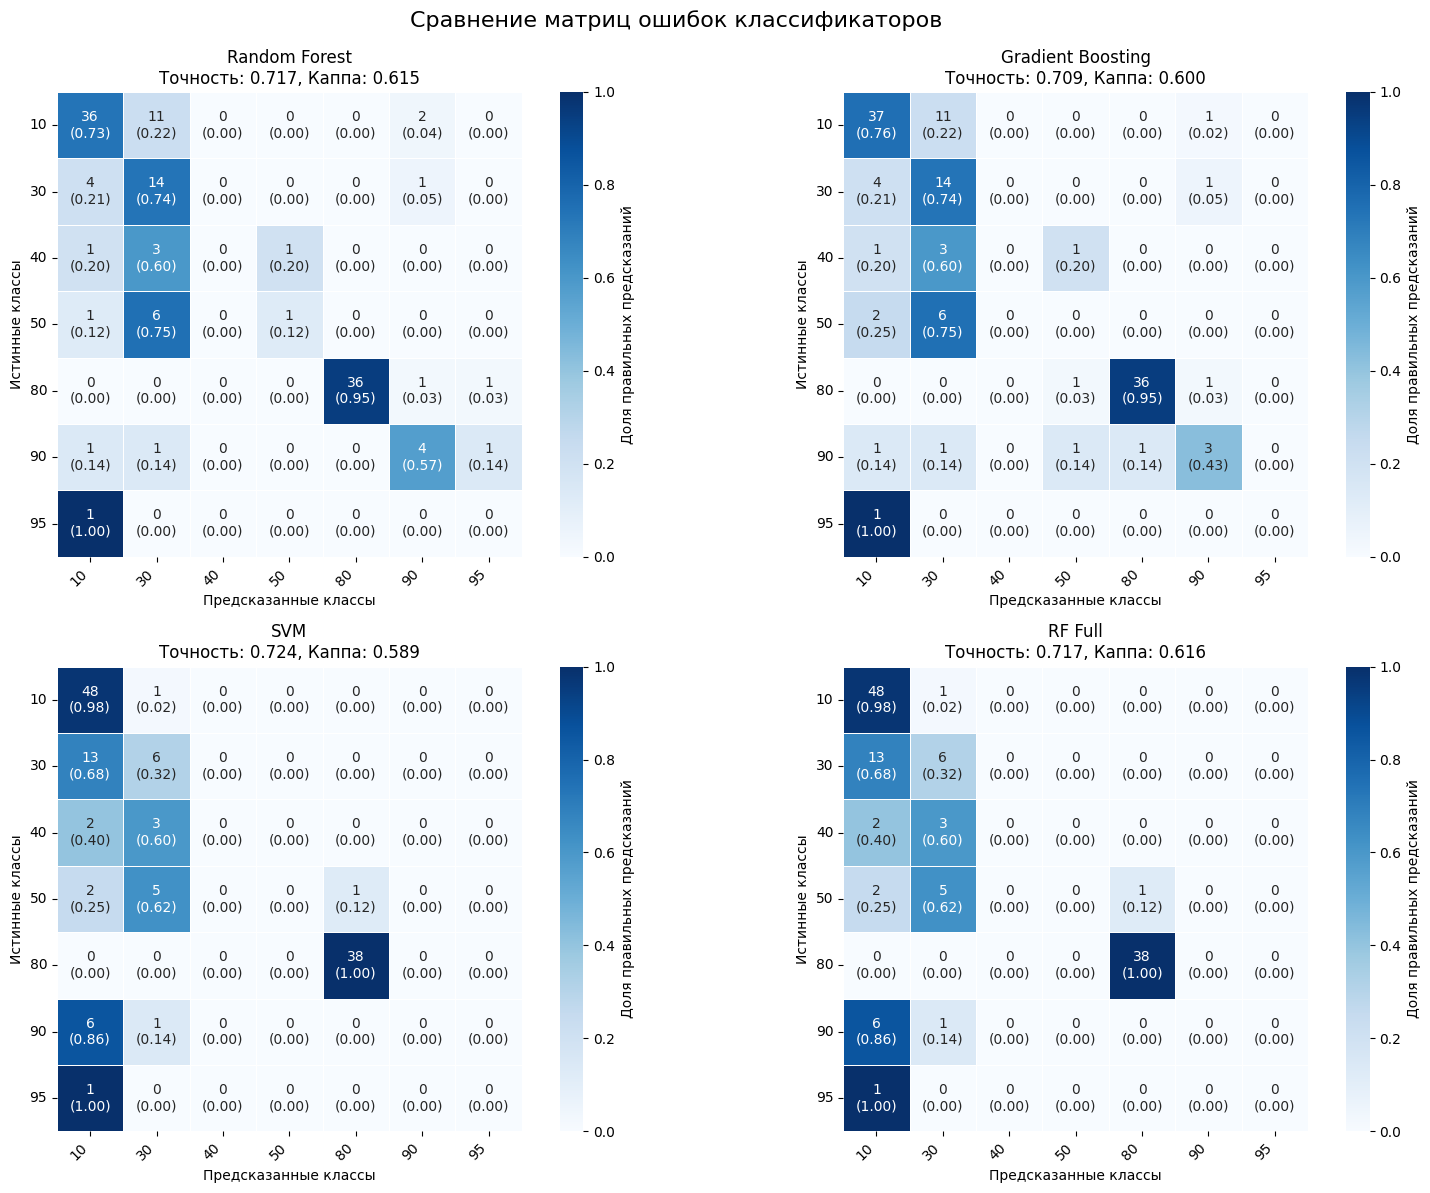

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def clean_matrix(cm):
    mask = (cm.sum(axis=1) > 0) | (cm.sum(axis=0) > 0)
    return cm[mask][:, mask], np.where(mask)[0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, data) in zip(axes, results.items()):
    cm, indices = clean_matrix(data['matrix'])

    with np.errstate(divide='ignore', invalid='ignore'):
        norm = np.nan_to_num(cm / cm.sum(axis=1)[:, None])

    annot = [[f"{int(cm[i,j])}\n({norm[i,j]:.2f})"
              for j in range(len(cm))]
              for i in range(len(cm))]

    sns.heatmap(norm,
                annot=annot,
                fmt='',
                cmap='Blues',
                square=True,
                cbar_kws={'label': 'Доля правильных предсказаний'},
                ax=ax,
                linewidths=0.5,
                vmin=0,
                vmax=1)

    class_labels = [f'{i}' for i in indices]
    ax.set_xticklabels(class_labels, rotation=45, ha='right')
    ax.set_yticklabels(class_labels, rotation=0)
    ax.set_title(f"{name}\nТочность: {data['accuracy']:.3f}, "
                 f"Каппа: {data['kappa']:.3f}", fontsize=12)
    ax.set_xlabel('Предсказанные классы')
    ax.set_ylabel('Истинные классы')

if len(results) < len(axes):
    for i in range(len(results), len(axes)):
        fig.delaxes(axes[i])

plt.suptitle('Сравнение матриц ошибок классификаторов', fontsize=16, y=0.99)
plt.tight_layout()
plt.show()


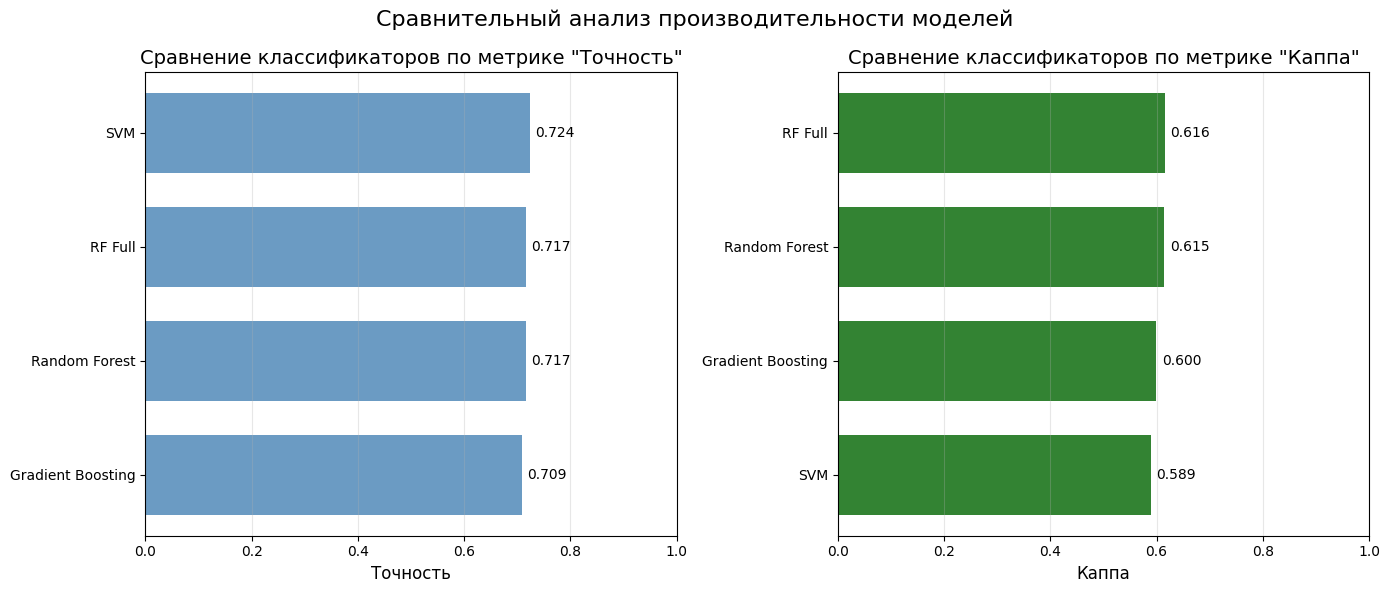

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    name: {'Точность': r['accuracy'], 'Каппа': r['kappa']}
    for name, r in results.items()
}).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, color in [(ax1, 'Точность', 'steelblue'),
                          (ax2, 'Каппа', 'darkgreen')]:
    sorted_df = metrics_df.sort_values(metric)
    bars = ax.barh(sorted_df.index, sorted_df[metric],
                   color=color, height=0.7, alpha=0.8)

    ax.set_xlabel(metric, fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_title(f'Сравнение классификаторов по метрике "{metric}"',
                 fontsize=14)
    ax.grid(axis='x', alpha=0.3)

    for bar, value in zip(bars, sorted_df[metric]):
        ax.text(value + 0.01, bar.get_y() + bar.get_height()/2,
                f'{value:.3f}', va='center', fontsize=10)

plt.suptitle('Сравнительный анализ производительности моделей', fontsize=16)
plt.tight_layout()
plt.show()


7.13. Выберите лучшую модель по метрике Каппа и примените её для **классификации всей новой области интереса (выберите ее на карте, также, как делали это вначале)**. Отобразите результат на карте с легендой классов.

In [92]:
new_region = m.user_roi
if new_region is None:
    new_region = ee.Geometry.BBox(-83.5, 39.5, -82.5, 40.5)

new_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(new_region)
                  .filterDate('2023-05-01', '2023-09-30')
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                  .map(mask_clouds))

new_composite = new_collection.median().clip(new_region)

def add_indices_local(img):
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
    ndbi = img.normalizedDifference(['B11', 'B8']).rename('NDBI')
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {
            'NIR': img.select('B8'),
            'RED': img.select('B4'),
            'BLUE': img.select('B2')
        }
    ).rename('EVI')
    return img.addBands([ndvi, ndwi, ndbi, evi])

new_composite = add_indices_local(new_composite)

best_model_name = 'Random Forest'
bands_for_prediction = all_bands

new_classified = new_composite.select(bands_for_prediction).classify(models[best_model_name])

m2 = geemap.Map()
m2.center_object(new_region, 10)

esa_vis = {'min': 10, 'max': 100, 'palette': ['006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000', 'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75', '966400']}

m2.add_layer(new_composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'New Image RGB')
m2.add_layer(new_classified, esa_vis, 'Classification Result')
m2.add_legend(title="ESA Land Cover", builtin_legend='ESA_WorldCover')

m2

Map(center=[39.99913765421407, -83], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

7.14. **Экспортируйте результат** классификации в формате GeoTIFF с сохранением геопривязки.

In [93]:
import os

out_dir = os.path.expanduser('~')
out_file = os.path.join(out_dir, 'classification_result.tif')

geemap.ee_export_image(
    new_classified,
    filename=out_file,
    scale=10,
    region=region,
    file_per_band=False
)

print(f"Файл сохранен: {out_file}")

Generating URL ...
An error occurred while downloading.
Pixel grid dimensions (89057x77924) must be less than or equal to 32768.
Файл сохранен: /root/classification_result.tif
